In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Checking cols datatypes and null count

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **TotalCharges col has some blank values because tenure of those customers is zero so replace them with zero and change the data type**

In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype(float)

# Standardize senior citizen col

In [6]:
df["SeniorCitizen"] = df["SeniorCitizen"].replace([1,0],["Yes","No"])
df["SeniorCitizen"]

0        No
1        No
2        No
3        No
4        No
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: SeniorCitizen, Length: 7043, dtype: object

# **Descriptive Analysis**

In [7]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

[Text(0, 0, '5174'), Text(0, 0, '1869')]

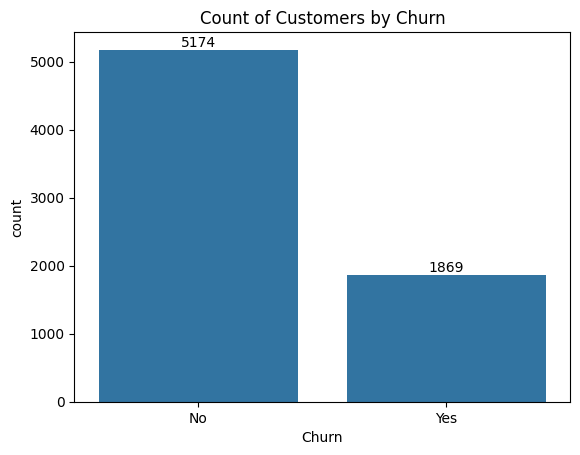

In [9]:
plt.title('Count of Customers by Churn')
ax = sns.countplot(x = "Churn", data = df)
ax.bar_label(ax.containers[0])

([<matplotlib.patches.Wedge at 0x1a1fe8f5a90>,
 [Text(-0.7393678155529122, 0.8144539479458092, 'No'),
  Text(0.7393680809356542, -0.8144537070291521, 'Yes')],
 [Text(-0.40329153575613386, 0.4442476079704413, '73.46%'),
  Text(0.4032916805103568, -0.44424747656135566, '26.54%')])

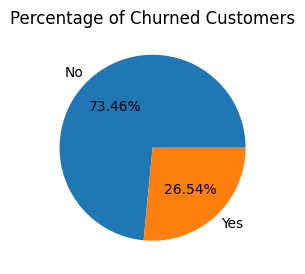

In [10]:

plt.figure(figsize = (3,4))
plt.title("Percentage of Churned Customers")
gb = df.groupby("Churn").agg({"Churn":"count"})

plt.pie(gb["Churn"],labels = gb.index,autopct = "%1.2f%%")


# From the given pie chart we can conclude that 26.54% customers have churned

# Let's explore the reason

[Text(0, 0, '2549'), Text(0, 0, '2625')]

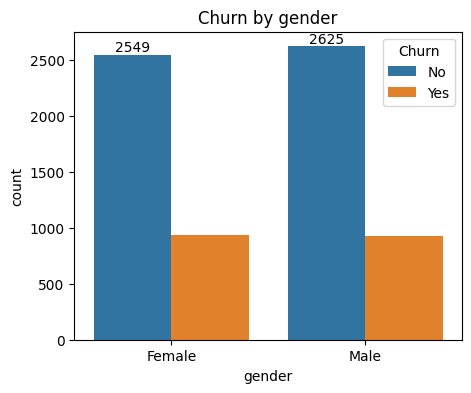

In [11]:
plt.figure(figsize = (5,4))
plt.title("Churn by gender")
ax = sns.countplot(x = 'gender',data = df,hue= "Churn")
ax.bar_label(ax.containers[0])

[Text(0, 0, '5901'), Text(0, 0, '1142')]

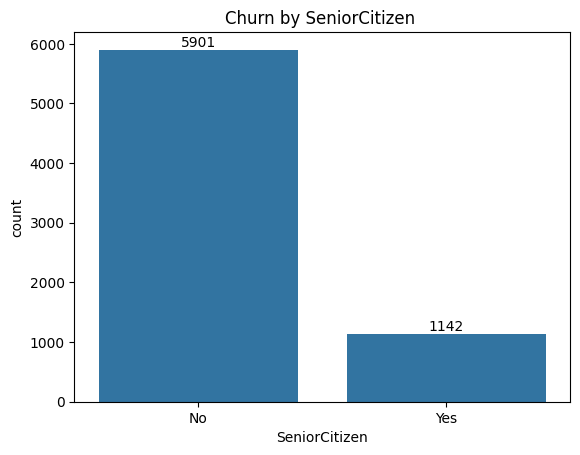

In [12]:
plt.title("Churn by SeniorCitizen ")
ax = sns.countplot(x = 'SeniorCitizen',data = df)
ax.bar_label(ax.containers[0])

[Text(0, 0, '4508'), Text(0, 0, '666')]

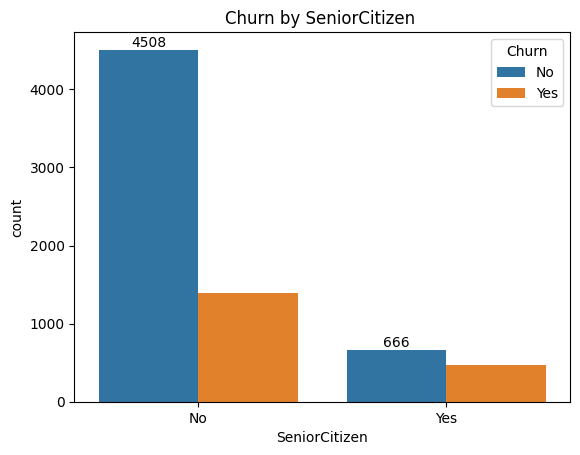

In [13]:
plt.title("Churn by SeniorCitizen ")
ax = sns.countplot(x = 'SeniorCitizen',data = df,hue="Churn")
ax.bar_label(ax.containers[0])


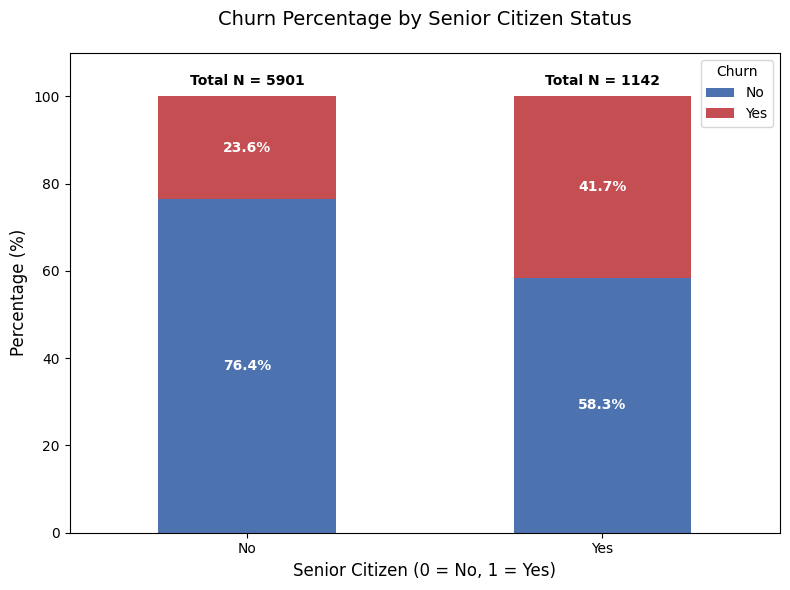

In [14]:
# 1. Create a normalized cross-tabulation for percentages (stacked bars)
# 'normalize="index"' ensures each SeniorCitizen category sums up to 100%
cross_tab_prop = pd.crosstab(index=df['SeniorCitizen'],
                             columns=df['Churn'],
                             normalize='index') * 100

# 2. Get the actual total counts for each SeniorCitizen category
totals = df.groupby('SeniorCitizen')['Churn'].count()

# 3. Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
cross_tab_prop.plot(kind='bar', 
                    stacked=True, 
                    color=['#4c72b0', '#c44e52'], # Classic Seaborn-like colors
                    ax=ax)

# 4. Add percentage labels inside the stacked bar segments
for container in ax.containers:
    # Format labels to show the percentage value inside each segment
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold')

# 5. Add the total number of customers at the very top of each stacked bar
# We use the total counts we calculated in step 2
for i, total in enumerate(totals):
    ax.text(i, 102, f'Total N = {total}', ha='center', va='bottom', fontweight='bold', color='black')

# 6. Clean up the aesthetics
plt.title("Churn Percentage by Senior Citizen Status", fontsize=14, pad=20)
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.ylim(0, 110) # Leave room at the top for the total count labels
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()

plt.show()

# More people Who are senior citizens are churned out as compare to those who are not senior citizen

<Axes: xlabel='tenure', ylabel='Count'>

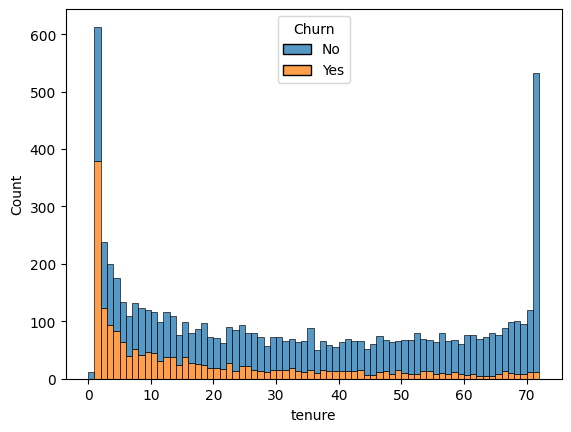

In [19]:
sns.histplot(x="tenure", data=df, bins=72, hue="Churn", multiple="stack")

# Those People less churn out whome tenure is greater as compare to less tenure people.

[Text(0, 0, '2220'), Text(0, 0, '1307'), Text(0, 0, '1647')]

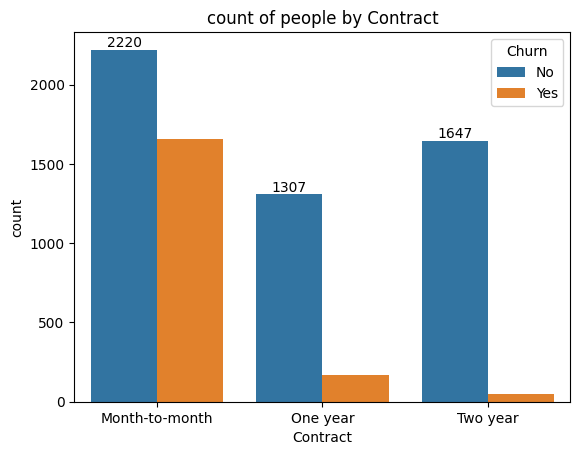

In [21]:
plt.title("count of people by Contract")
ax = sns.countplot(x = 'Contract',data = df,hue = "Churn")
ax.bar_label(ax.containers[0])

## People who have month to month contract are more likely to churn then from greater contract time period. 

In [22]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

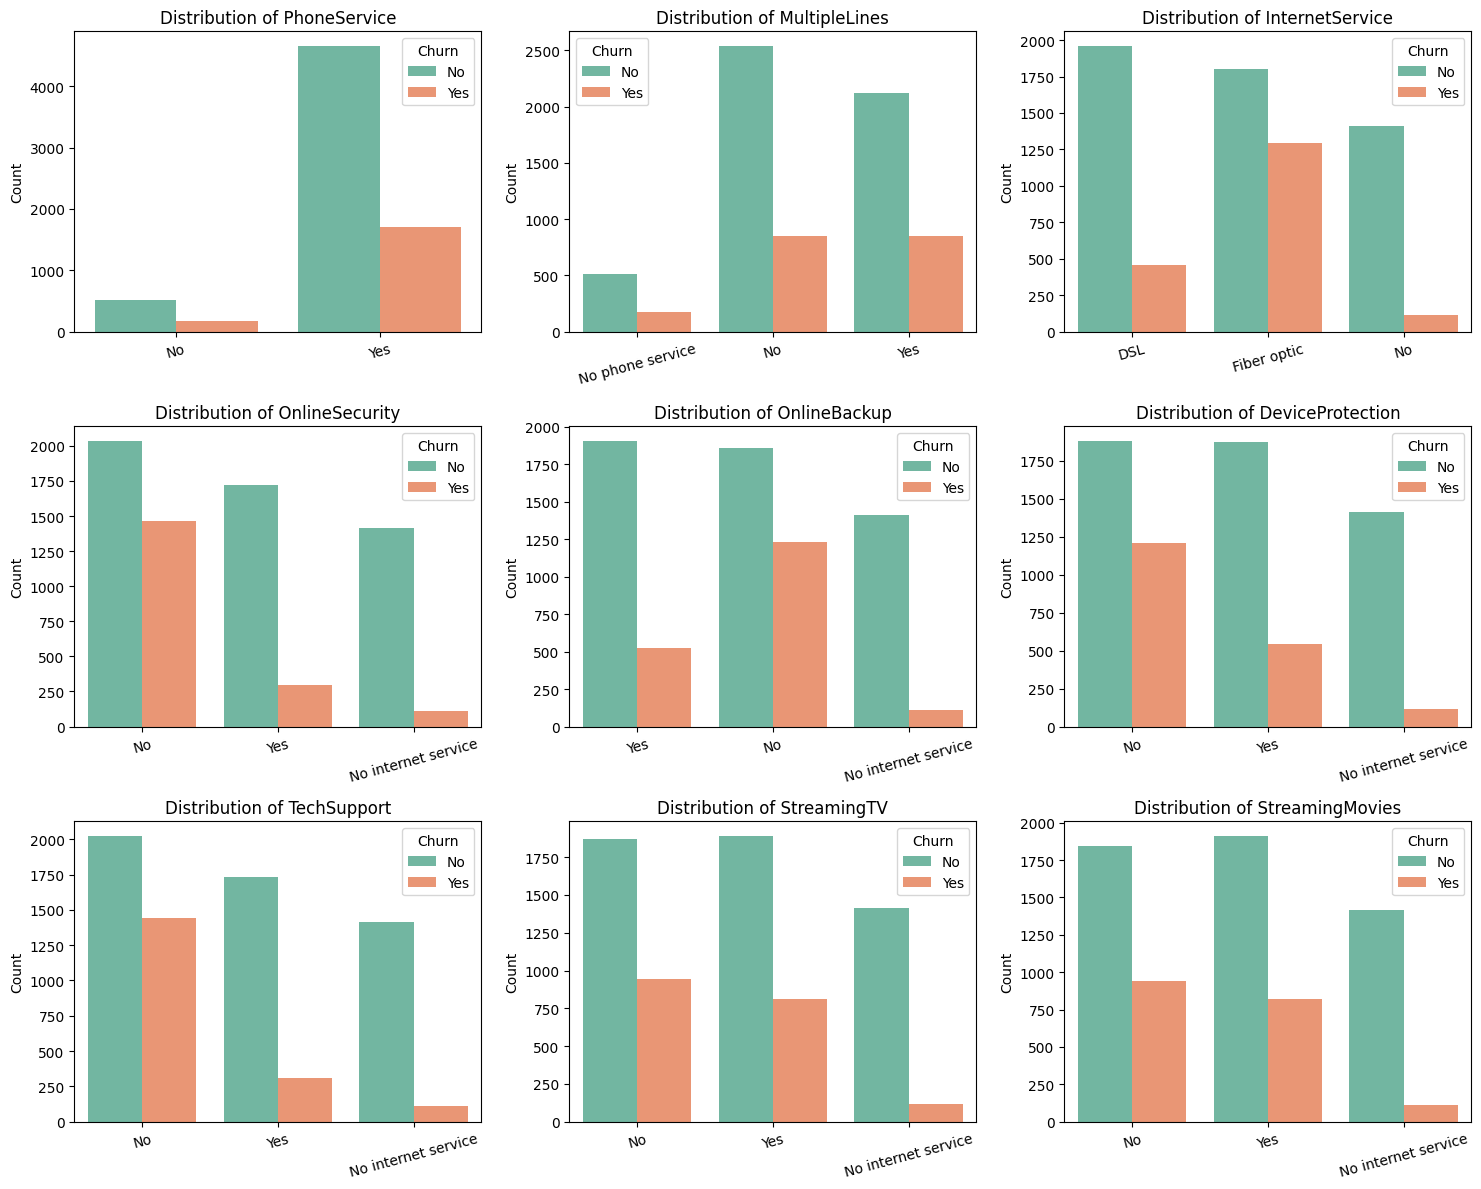

In [29]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Set up the matplotlib figure size (3 rows, 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Flatten the 3x3 axes array to a 1D array so we can loop through it easily
axes = axes.flatten()

# Loop through columns and create a countplot for each
for i, col in enumerate(cols):
    sns.countplot(
        x=col, 
        data=df, 
        ax=axes[i], 
        palette="Set2",
        hue="Churn"

    )
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')  # Clears the x-axis label to avoid crowding
    axes[i].set_ylabel('Count')
    
    # Optional: Rotate x-ticks if labels (like in InternetService) overlap
    axes[i].tick_params(axis='x', rotation=15)

# Adjust the layout so titles and labels don't overlap
plt.tight_layout()

### Those customers who are using fiber optic internet service are more likely to churn
### People who don't have Online security are also churning more
### People who don't have tech support are also churning more
### Those who don't have Online backup are also churning in greater amount
### Also those who don't have device protection are also churning

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

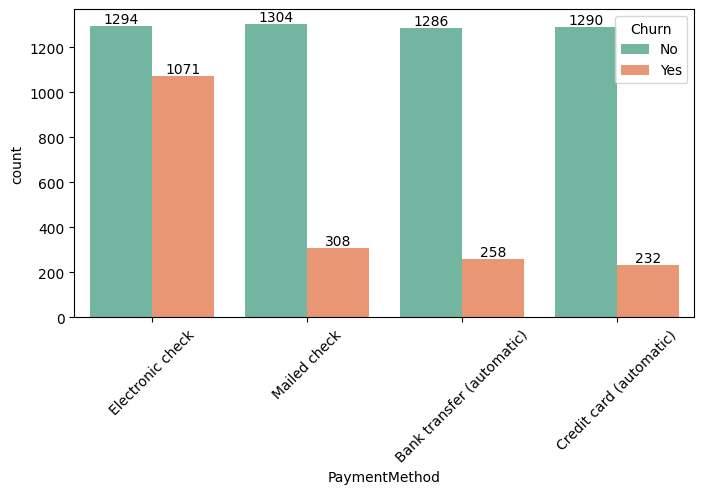

In [40]:
plt.figure(figsize=(8,4))
ax = sns.countplot(
        x="PaymentMethod", 
        data=df,  
        palette="Set2",
        hue="Churn"
    )
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation=45)

# Customer using Electronic check payment method are more likely to churn